# EDA — Corpus gold de criticidad

**Dataset:** `casos_gold_criticidad_v2.jsonl` (alternativa piloto: `casos_gold_criticidad_v1.jsonl`). Ubicación: `data/criticidad_cases/`.

**Objetivo:** caracterizar el conjunto etiquetado (`play` / `pausa` / `stop`) para la **política de criticidad** y preparar la evaluación frente al Sentinel / pipeline multi-agente.

---

### Criterios mínimos cubiertos en este notebook

1. **Estadísticas descriptivas básicas** — tipos, conteos, medidas de tendencia y dispersión para variables numéricas derivadas (`n_chars`, `n_words`), ausencia de nulos donde aplica.
2. **Distribución de variables clave** — frecuencia de la etiqueta gold, longitud del requerimiento, palabras.
3. **Riesgos identificados** — **desbalance** (equilibrio 100/100/100), **leakage léxico** (proxy por palabras clave), **drift** (limitaciones en snapshot estático y cómo monitorearlo en despliegue).

### Contenido adicional (útil para criticidad)

- Complejidad textual proxy (`chars_por_palabra`).
- Contraste `difficulty_hint` vs `gold_mode`.
- Matriz `gold_mode` × `template_index` para comprobar cobertura del diseño experimental.

**Metadatos (schema ≥ 2.2):** `template_index`, `tags`, `schema_version` — opcionales en JSONL mínimo; ver `src/criticidad_case_types.py`.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["font.size"] = 10

BASE = Path.cwd()
CANDIDATES = [
    BASE / "casos_gold_criticidad_v2.jsonl",
    BASE / "data" / "criticidad_cases" / "casos_gold_criticidad_v2.jsonl",
    BASE.parent / "casos_gold_criticidad_v2.jsonl",
    BASE / "casos_gold_criticidad_v1.jsonl",
    BASE / "data" / "criticidad_cases" / "casos_gold_criticidad_v1.jsonl",
    BASE.parent / "casos_gold_criticidad_v1.jsonl",
]
CASES_FILE = next((p for p in CANDIDATES if p.exists()), None)
if CASES_FILE is None:
    raise FileNotFoundError(
        "No se encontró casos_gold_criticidad_v2.jsonl ni casos_gold_criticidad_v1.jsonl. "
        "Compruebe que el JSONL esté en data/criticidad_cases/ (v2: 300 filas)."
    )
print("Archivo cargado:", CASES_FILE)


Archivo cargado: C:\Users\jlpy\Documents\UniMaestria\4Semestre\Proyecto de Investigacion 2\Tesis\data\criticidad_cases\casos_gold_criticidad_v2.jsonl


In [ ]:
rows = []
with open(CASES_FILE, encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))

df = pd.DataFrame(rows)
assert len(df) in (36, 300), len(df)
if CASES_FILE.name == "casos_gold_criticidad_v2.jsonl":
    assert len(df) == 300, "v2 debe tener 300 filas"

_g = df["gold_mode"].value_counts()
assert set(_g.values) == {len(df) // 3}, _g.to_dict()

if "template_index" in df.columns:
    df["template_index"] = pd.to_numeric(df["template_index"], errors="coerce").astype("Int64")

df["n_chars"] = df["requirement"].str.len()
df["n_words"] = df["requirement"].str.split().str.len()
df["chars_por_palabra"] = df["n_chars"] / df["n_words"].clip(lower=1)

print("schema_version:", df["schema_version"].dropna().unique().tolist() if "schema_version" in df.columns else "N/A")
df.head()


schema_version: ['2.2']


,id,gold_mode,requirement,rationale_gold,literature_axis,difficulty_hint,schema_version,template_index,tags,n_chars,n_words,chars_por_palabra
0,CRT-PLAY-001,play,Herramienta CLI que renombra lotes de imágenes...,"Alcance local/acotado, sin producción ni datos...",Contraste con tareas SWE multi-repo de alto im...,low,2.2,0,"[criticidad, play, template:00]",140,20,7.000000
1,CRT-PLAY-002,play,Herramienta CLI que convierte CSV a tablas Mar...,"Alcance local/acotado, sin producción ni datos...",Contraste con tareas SWE multi-repo de alto im...,low,2.2,0,"[criticidad, play, template:00]",127,18,7.055556
2,CRT-PLAY-003,play,Herramienta CLI que genera diagramas Mermaid a...,"Alcance local/acotado, sin producción ni datos...",Contraste con tareas SWE multi-repo de alto im...,low,2.2,0,"[criticidad, play, template:00]",140,21,6.666667
3,CRT-PLAY-004,play,Herramienta CLI que cuenta fallos en logs de p...,"Alcance local/acotado, sin producción ni datos...",Contraste con tareas SWE multi-repo de alto im...,low,2.2,0,"[criticidad, play, template:00]",146,23,6.347826
4,CRT-PLAY-005,play,Herramienta CLI que implementa un juego de adi...,"Alcance local/acotado, sin producción ni datos...",Contraste con tareas SWE multi-repo de alto im...,low,2.2,0,"[criticidad, play, template:00]",149,20,7.450000


## 1. Estadísticas descriptivas básicas

Aquí resumimos **forma del dataset**, **tipos**, **valores faltantes** y **estadísticos** de las variables numéricas derivadas del texto del requerimiento.

**Interpretación:** si los nulos son cero en columnas obligatorias (`id`, `gold_mode`, `requirement`), el JSONL está completo; `describe()` permite comparar dispersión de longitudes entre futuras ejecuciones (referencia para detectar **drift** cuando existan nuevas versiones del corpus).


In [3]:
display(df.dtypes.to_frame("dtype"))

nulos = df.isnull().sum().sort_values(ascending=False)
display(nulos.to_frame("nulos"))

num_cols = ["n_chars", "n_words", "chars_por_palabra"]
if "template_index" in df.columns:
    num_cols.append("template_index")
display(df[num_cols].describe().T.round(3))

if "difficulty_hint" in df.columns:
    display(pd.crosstab(df["gold_mode"], df["difficulty_hint"], margins=True))


,dtype
id,object
gold_mode,object
requirement,object
rationale_gold,object
literature_axis,object
difficulty_hint,object
schema_version,object
template_index,Int64
tags,object
n_chars,int64


,nulos
id,0
gold_mode,0
requirement,0
rationale_gold,0
literature_axis,0
difficulty_hint,0
schema_version,0
template_index,0
tags,0
n_chars,0


,count,mean,std,min,25%,50%,75%,max
n_chars,300.0,162.133333,28.041099,102.0,140.75,155.0,189.0,218.0
n_words,300.0,23.103333,3.863818,14.0,20.0,23.0,26.0,33.0
chars_por_palabra,300.0,7.031801,0.546779,5.7,6.683612,6.95,7.28836,9.0
template_index,300.0,4.5,2.87708,0.0,2.0,4.5,7.0,9.0


difficulty_hint,high,low,medium,All
gold_mode,,,,
pausa,0,0,100,100
play,0,100,0,100
stop,100,0,0,100
All,100,100,100,300


## 2. Distribución de variables clave

### 2.1 Etiqueta gold (`gold_mode`)

**Figura 1 — Barras de conteo por clase.** Muestra si las tres políticas de ejecución (`play`, `pausa`, `stop`) están representadas por igual. En el diseño v2 (**n=300**) se esperan **100** casos por clase; cualquier desviación fuerte indicaría **desbalance** y obligaría a métricas estratificadas o ponderadas (p. ej. F1-macro).


,n
gold_mode,
play,100
pausa,100
stop,100


χ² vs equiprobabilidad 33/33/33 (ref., 2 g.l.): 0.0


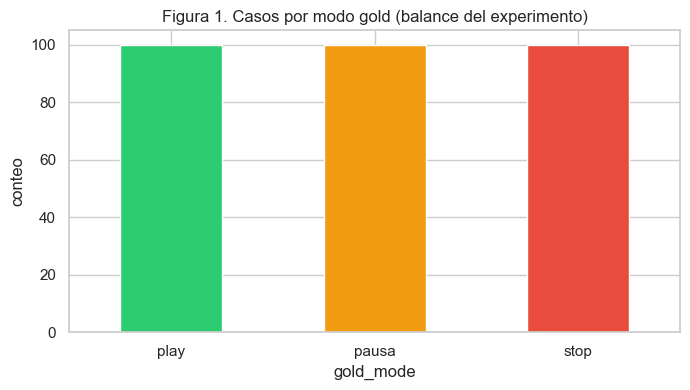

In [4]:
vc = df["gold_mode"].value_counts().reindex(["play", "pausa", "stop"], fill_value=0)
display(vc.to_frame("n"))

fig, ax = plt.subplots(figsize=(7, 4))
vc.plot(kind="bar", ax=ax, color=["#2ecc71", "#f39c12", "#e74c3c"])
ax.set_title("Figura 1. Casos por modo gold (balance del experimento)")
ax.set_xlabel("gold_mode")
ax.set_ylabel("conteo")
plt.xticks(rotation=0)

n_tot = len(df)
esp = n_tot / 3.0
chi2_balance = sum(((vc.loc[m] - esp) ** 2) / esp for m in ["play", "pausa", "stop"])
print("χ² vs equiprobabilidad 33/33/33 (ref., 2 g.l.):", float(chi2_balance))

plt.tight_layout()
plt.show()


### 2.2 Longitud del texto del requerimiento (`n_chars`)

**Figura 2 — Histograma global de caracteres.** Resume la variabilidad de redacción: textos más largos pueden asociarse a más contexto operativo (no implican solos mayor criticidad).

**Figura 3 — Cajas por clase.** Compara medianas y dispersión entre `play`, `pausa` y `stop`. Solapes grandes sugieren que el clasificador no puede basarse solo en longitud (desirable para evitar atajos superficiales).


n_chars                                                    n_words  \
            count   mean    std    min     25%    50%     75%    max   count   
gold_mode                                                                      
pausa       100.0  151.5  13.65  114.0  143.00  152.0  161.00  180.0   100.0   
play        100.0  138.3  12.49  102.0  128.75  139.0  148.25  168.0   100.0   
stop        100.0  196.6  12.02  162.0  189.00  199.0  206.00  218.0   100.0   

                  ...             chars_por_palabra                          \
            mean  ...   75%   max             count  mean   std   min   25%   
gold_mode         ...                                                         
pausa      21.90  ...  23.0  27.0             100.0  6.94  0.57  5.70  6.54   
play       19.90  ...  21.0  25.0             100.0  6.97  0.41  6.19  6.70   
stop       27.51  ...  29.0  33.0             100.0  7.18  0.62  6.17  6.74   

                             
            50%   75%   max  
gold_mode                    
pausa      6.87  7.24  9.00  
play       6.95  7.20  8.21  
stop       7.00  7.66  8.87  

[3 rows x 24 columns]

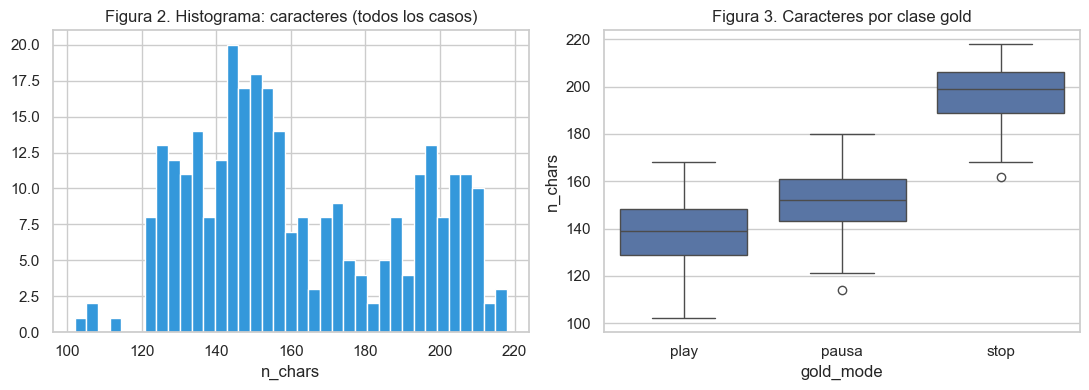

In [5]:
display(df.groupby("gold_mode")[["n_chars", "n_words", "chars_por_palabra"]].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
bins_n = min(40, max(15, len(df) // 8))
df["n_chars"].hist(ax=axes[0], bins=bins_n, color="#3498db", edgecolor="white")
axes[0].set_title("Figura 2. Histograma: caracteres (todos los casos)")
axes[0].set_xlabel("n_chars")

sns.boxplot(data=df, x="gold_mode", y="n_chars", order=["play", "pausa", "stop"], ax=axes[1])
axes[1].set_title("Figura 3. Caracteres por clase gold")

plt.tight_layout()
plt.show()


### 2.3 Número de palabras (`n_words`)

**Figura 4 — Violín por clase.** Similar al análisis de caracteres pero en unidades léxicas; útil para detectar si una clase tiende a enunciados más elaborados.


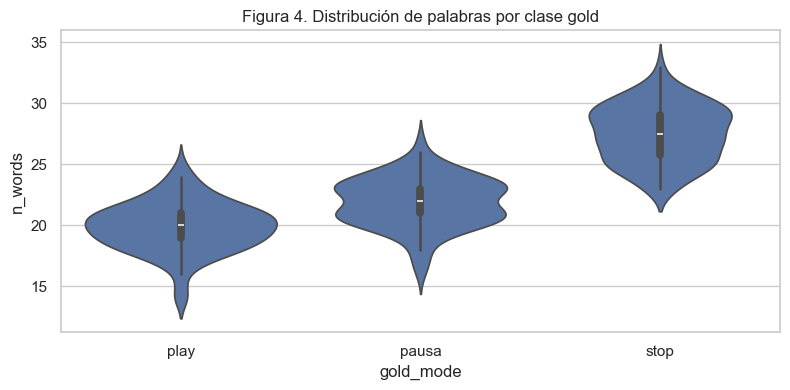

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.violinplot(data=df, x="gold_mode", y="n_words", order=["play", "pausa", "stop"], ax=ax)
ax.set_title("Figura 4. Distribución de palabras por clase gold")
plt.tight_layout()
plt.show()


### 2.4 Plantillas (`template_index`) y cobertura del diseño

**Figura 5 — Mapa de calor conteos.** En v2 hay **10** categorías de `template_index` por clase; cada celda debería tener **10** casos. Patrones vacíos o muy desiguales indicarían inconsistencia en el conjunto o corpus incompleto.


template_index,0,1,2,3,4,5,6,7,8,9
gold_mode,,,,,,,,,,
pausa,10,10,10,10,10,10,10,10,10,10
play,10,10,10,10,10,10,10,10,10,10
stop,10,10,10,10,10,10,10,10,10,10


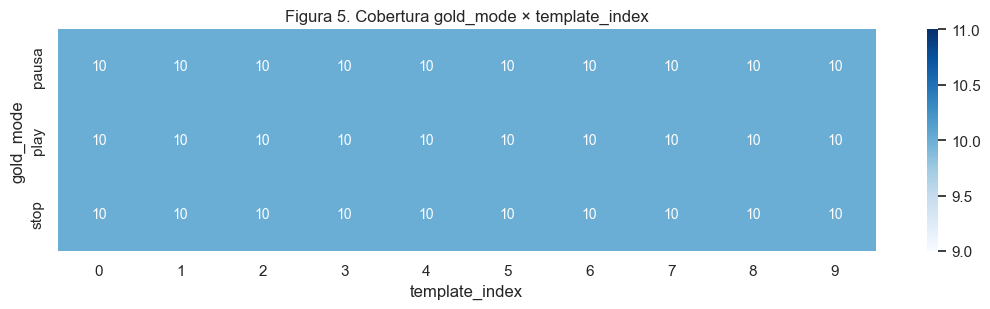

In [7]:
if "template_index" in df.columns and df["template_index"].notna().any():
    ct = pd.crosstab(df["gold_mode"], df["template_index"])
    display(ct)
    fig, ax = plt.subplots(figsize=(11, 3.2))
    sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title("Figura 5. Cobertura gold_mode × template_index")
    plt.tight_layout()
    plt.show()
else:
    print("Sin columna template_index (JSONL reducido o v1 sin metadatos).")


### 2.5 Complejidad textual proxy (`chars_por_palabra`)

**Figura 6 — Palabras más largas vs más cortas por caso.** Ratio alto puede indicar términos técnicos largos (tokens compuestos); sirve como control descriptivo, no como etiqueta de riesgo.


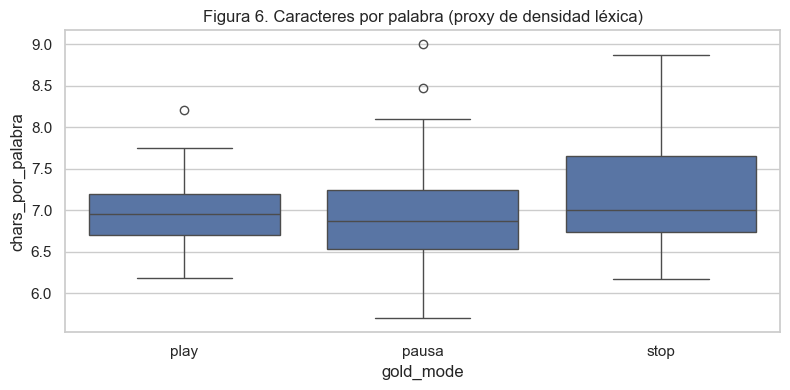

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df, x="gold_mode", y="chars_por_palabra", order=["play", "pausa", "stop"], ax=ax)
ax.set_title("Figura 6. Caracteres por palabra (proxy de densidad léxica)")
plt.tight_layout()
plt.show()


## 3. Riesgos identificados (leakage, desbalance, drift)

### 3.1 Desbalance entre clases

En **v2** el diseño fuerza **100** observaciones por `gold_mode`. La Figura 1 y el χ² de referencia sirven para confirmarlo. Si en el futuro se agregan casos solo de una clase, las métricas globales deben complementarse con **macro-F1** o **balanced accuracy** y reportar prevalencias.

### 3.2 Leakage léxico (proxy)

Si ciertas palabras predicen la clase gold sin ambigüedad, un modelo podría **memorizar lexicon** en lugar de estimar criticidad semántica.

**Figura 7 — Calor de proporciones:** presencia binaria de patrones en el texto (heurística). Valores cercanos a 0 o 1 en una clase sugieren riesgo de leakage para esa keyword.

### 3.3 Drift de datos

Este corpus es un **snapshot estático**: **no hay marca temporal** por caso; por tanto **no es posible medir drift temporal dentro del notebook**. En producción conviene comparar distribuciones de longitud, scores del Sentinel o tasas de error por cohorte temporal.

---


,kw_prod,kw_datos_pers,kw_pago_pci,kw_auth,kw_local_safe
gold_mode,,,,,
pausa,0.40,0.20,0.10,0.0,0.10
play,0.10,0.20,0.00,0.0,0.52
stop,0.21,0.15,0.11,0.1,0.01


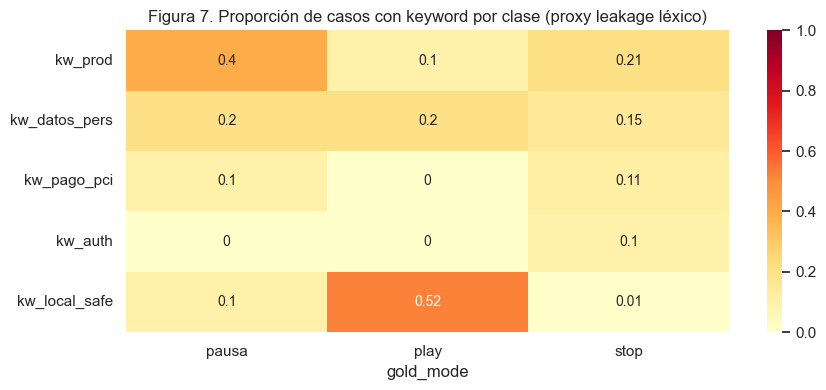

In [9]:
KEYWORDS = {
    "kw_prod": r"producci[oó]n|productivo|\bprod\b",
    "kw_datos_pers": r"personal|GDPR|PII|clientes",
    "kw_pago_pci": r"pago|PCI|tarjeta|token",
    "kw_auth": r"OAuth|JWT|autenticaci[oó]n|IAM",
    "kw_local_safe": r"local|sint[eé]tico|laboratorio|sin red",
}
text_lower = df["requirement"].str.lower()
for col, pat in KEYWORDS.items():
    df[col] = text_lower.str.contains(pat, regex=True, na=False)

kw_cols = list(KEYWORDS.keys())
display(df.groupby("gold_mode")[kw_cols].mean().round(3))

plt.figure(figsize=(9, 4))
hm = df.groupby("gold_mode")[kw_cols].mean()
sns.heatmap(hm.T, annot=True, cmap="YlOrRd", vmin=0, vmax=1)
plt.title("Figura 7. Proporción de casos con keyword por clase (proxy leakage léxico)")
plt.tight_layout()
plt.show()


## 4. Síntesis

| Aspecto | Hallazgo esperado (v2) | Acción si falla |
|---------|------------------------|-----------------|
| Balance | 100 por clase | Revisar muestreo o filtrado del conjunto |
| Longitud | Solapes entre clases | Reforzar datos límite / contrafactuales |
| Keywords | Separación extrema por banda | Parafrasear casos o enriquecer negativos |
| Drift | N/A en CSV único | Versionar corpus y repetir EDA comparativo |


